# TakeMeter — Fine-Tuning Starter Notebook
### AI201 · Project 3

This notebook walks you through fine-tuning a text classifier on your annotated dataset and comparing it to a zero-shot baseline.

**What this notebook does for you (infrastructure):**
- Tokenizes your dataset and prepares it for training
- Runs the fine-tuning pipeline with DistilBERT
- Computes evaluation metrics and generates a confusion matrix
- Runs the Groq baseline and compares both models

**What you do (the actual work):**
- Collect and annotate your 200+ examples (done before opening this notebook)
- Define your label map and upload your CSV
- Write your Groq classification prompt using your label definitions
- Analyze the output and write your evaluation report

---
**Before you start:** Make sure you are using a T4 GPU runtime.  
Go to **Runtime → Change runtime type → T4 GPU**, then click Save.

In [28]:
# Install any dependencies not pre-installed on Colab
!pip install -q groq python-dotenv
print("✅ Dependencies ready")

✅ Dependencies ready


In [3]:
import pandas as pd
import numpy as np
import json
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset
import warnings
warnings.filterwarnings("ignore")

print("✅ Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ Imports complete
PyTorch version: 2.11.0+cu130
GPU available: True
GPU: Tesla T4


---
## Section 1: Load Your Dataset

Upload your labeled CSV and define your label map.  
Your CSV must have at least two columns: `text` (the post/comment) and `label` (your string label).

In [29]:
# ── TODO ──────────────────────────────────────────────────────────────────
# Define YOUR label map below.
# Keys are the string labels in your CSV; values are integers starting at 0.
# Add or remove entries to match your actual labels (2–4 labels supported).
#
# The example below is ILLUSTRATIVE ONLY (the r/nba taxonomy from the project
# page). DELETE it and use your own community's labels — submitting the
# example unchanged will not pass.
# ────────────────────────────────────────────────────────────────────────

LABEL_MAP = {
    "tips": 0,
    "reviews": 1,
    "changes": 2,
    "confusion": 3,
}

# ── END TODO ──────────────────────────────────────────────────────────────

ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_LABELS = len(LABEL_MAP)
print(f"Labels: {LABEL_MAP}")
print(f"Number of labels: {NUM_LABELS}")

Labels: {'tips': 0, 'reviews': 1, 'changes': 2, 'confusion': 3}
Number of labels: 4


In [30]:
# Upload your CSV from your computer
from google.colab import files
print("Select your labeled dataset CSV file...")
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]
print(f"Uploaded: {CSV_PATH}")

Select your labeled dataset CSV file...


Saving Takemeter dataset.csv to Takemeter dataset (1).csv
Uploaded: Takemeter dataset (1).csv


In [31]:
# Load and validate your dataset
df = pd.read_csv(CSV_PATH)

# ── TODO (if needed) ──────────────────────────────────────────────────────
# If your CSV uses different column names, rename them here.
# Example: df = df.rename(columns={"post": "text", "category": "label"})
# ── END TODO ──────────────────────────────────────────────────────────────

print(f"Columns: {df.columns.tolist()}")
print(f"Total examples: {len(df)}")
print()
print("Label distribution:")
print(df["label"].value_counts())

# Validate all labels are in LABEL_MAP
unknown = set(df["label"].unique()) - set(LABEL_MAP.keys())
if unknown:
    print(f"\n⚠️  Labels in CSV not found in LABEL_MAP: {unknown}")
    print("Update your LABEL_MAP above to include all labels.")
else:
    print("\n✅ All labels match your LABEL_MAP")

# Convert string labels to integers
df["label_id"] = df["label"].map(LABEL_MAP)
df = df.dropna(subset=["label_id"])
df["label_id"] = df["label_id"].astype(int)

Columns: ['label', 'text', 'Notes']
Total examples: 203

Label distribution:
label
reviews      87
tips         60
changes      49
confusion     7
Name: count, dtype: int64

✅ All labels match your LABEL_MAP


---
## Section 2: Prepare Data for Training

Splits your dataset into train / validation / test sets and tokenizes the text.

In [32]:
# Train / val / test split — 70% / 15% / 15%
# Stratified so each split has roughly the same label distribution.
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label_id"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["label_id"]
)

print(f"Train: {len(train_df)} examples")
print(f"Validation: {len(val_df)} examples")
print(f"Test: {len(test_df)} examples")
print()
print("Train label distribution:")
print(train_df["label"].value_counts())
print()
print("Test label distribution:")
print(test_df["label"].value_counts())

# Reset indices (needed for clean HuggingFace Dataset conversion)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

Train: 142 examples
Validation: 30 examples
Test: 31 examples

Train label distribution:
label
reviews      61
tips         42
changes      34
confusion     5
Name: count, dtype: int64

Test label distribution:
label
reviews      13
tips          9
changes       8
confusion     1
Name: count, dtype: int64


In [33]:
# Load tokenizer and tokenize all splits
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(examples):
    return tokenizer(examples["text"], truncation=True, max_length=256)

def make_dataset(df_split):
    ds = Dataset.from_pandas(
        df_split[["text", "label_id"]].rename(columns={"label_id": "labels"})
    )
    return ds.map(tokenize, batched=True)

train_dataset = make_dataset(train_df)
val_dataset   = make_dataset(val_df)
test_dataset  = make_dataset(test_df)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("✅ Tokenization complete")
print(f"Sample keys: {list(train_dataset[0].keys())}")

Map:   0%|          | 0/142 [00:00<?, ? examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

Map:   0%|          | 0/31 [00:00<?, ? examples/s]

✅ Tokenization complete
Sample keys: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']


---
## Section 3: Fine-Tune Your Model

Loads `distilbert-base-uncased` with a classification head and fine-tunes it on your training data.  
Training runs for 3 epochs and takes **5–15 minutes** on a T4 GPU.

> **Hyperparameter note:** The defaults below work well for datasets of 100–500 examples.  
> If you change any values, note what you changed and why in your README.

In [9]:
# Load DistilBERT with a classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID_TO_LABEL,
    label2id=LABEL_MAP,
)
print(f"✅ Model loaded: {MODEL_NAME}")
print(f"Output labels: {NUM_LABELS}")

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded: distilbert-base-uncased
Output labels: 4


In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

In [63]:
# ── Hyperparameters ───────────────────────────────────────────────────────
# num_train_epochs  — passes through the training data; 3 is a good default
#                     for small datasets. Increase cautiously; more epochs
#                     risk overfitting on 200 examples.
# learning_rate     — 2e-5 is the standard starting point for fine-tuning
#                     BERT-family models. Lower → slower but more stable.
# per_device_train_batch_size — 16 fits T4 GPU comfortably.
#                     Reduce to 8 if you get out-of-memory errors.
# ─────────────────────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir="./takemeter-model",
    num_train_epochs=6,
    per_device_train_batch_size=12,
    per_device_eval_batch_size=32,
    learning_rate=3e-5,
    weight_decay=0.01,
    warmup_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=10,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting fine-tuning... (5–15 minutes on T4 GPU)")
trainer.train()
print("\n✅ Fine-tuning complete")

Starting fine-tuning... (5–15 minutes on T4 GPU)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.165962,0.673643,0.733333
2,0.119879,0.694868,0.733333
3,0.140381,0.754974,0.766667
4,0.065994,0.837165,0.700000
5,0.035775,0.920940,0.733333
6,0.029865,0.893287,0.700000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Fine-tuning complete


---
## Section 4: Evaluate Fine-Tuned Model on Test Set

Runs inference on your locked test set and generates metrics and a confusion matrix.  
These numbers go directly into your evaluation report.

In [64]:
# Run inference on the test set
print("Running inference on test set...")
ft_output = trainer.predict(test_dataset)
ft_pred_ids = np.argmax(ft_output.predictions, axis=-1)
ft_true_ids = ft_output.label_ids

ft_probs = torch.nn.functional.softmax(
    torch.tensor(ft_output.predictions), dim=-1
).numpy()

# Overall accuracy
ft_accuracy = accuracy_score(ft_true_ids, ft_pred_ids)
print(f"\n🎯 Fine-tuned model accuracy: {ft_accuracy:.3f}")

# Per-class metrics
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("\nPer-class metrics (fine-tuned model):")
print(classification_report(ft_true_ids, ft_pred_ids, target_names=label_names, zero_division=0))

Running inference on test set...



🎯 Fine-tuned model accuracy: 0.806

Per-class metrics (fine-tuned model):
              precision    recall  f1-score   support

        tips       0.90      1.00      0.95         9
     reviews       0.73      0.85      0.79        13
     changes       0.83      0.62      0.71         8
   confusion       0.00      0.00      0.00         1

    accuracy                           0.81        31
   macro avg       0.62      0.62      0.61        31
weighted avg       0.78      0.81      0.79        31



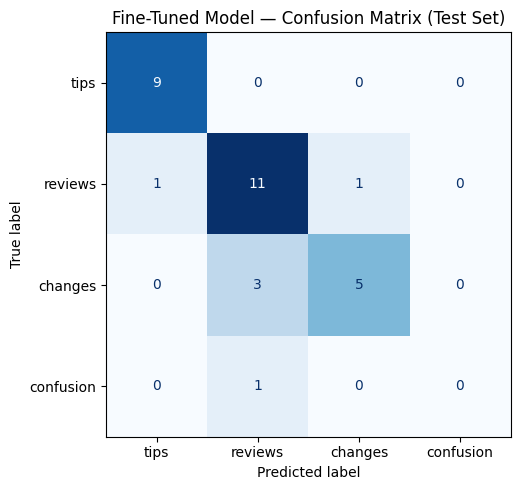

✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README


In [65]:
# Confusion matrix
cm = confusion_matrix(ft_true_ids, ft_pred_ids)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Fine-Tuned Model — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README")

In [66]:
# Print wrong predictions for your error analysis
# Review these carefully — pick 3 to analyze in depth in your README.

wrong_idx = np.where(ft_pred_ids != ft_true_ids)[0]
print(f"Wrong predictions: {len(wrong_idx)} / {len(ft_true_ids)}\n")

for i, idx in enumerate(wrong_idx[:15]):
    text = test_df.iloc[idx]["text"]
    true_label = ID_TO_LABEL[ft_true_ids[idx]]
    pred_label = ID_TO_LABEL[ft_pred_ids[idx]]
    confidence = ft_probs[idx][ft_pred_ids[idx]]
    print(f"--- #{i+1} ---")
    print(f"Text:      {text[:200]}{'...' if len(text) > 200 else ''}")
    print(f"True:      {true_label}")
    print(f"Predicted: {pred_label}  (confidence: {confidence:.2f})")
    print()

Wrong predictions: 6 / 31

--- #1 ---
Text:      For some reason I had to add a lot of extra flour, but they were really good!
True:      changes
Predicted: reviews  (confidence: 0.73)

--- #2 ---
Text:      Don’t make these if you want to be able to enjoy other food. They will blow your fucking tastebuds away. 🚫🧢
True:      reviews
Predicted: tips  (confidence: 0.96)

--- #3 ---
Text:      I made these and everyone loved them!! I mistakenly added a little extra cup of flour and so they aren't flat but the taste was still amazing! Will definitely make them again.
True:      changes
Predicted: reviews  (confidence: 0.94)

--- #4 ---
Text:      This is my favorite cookie recipe of all time. I follow the written instructions for the recipe, but I chill the dough in a roll shape instead of balls. It saves a lot of storage space and it’s super ...
True:      changes
Predicted: reviews  (confidence: 0.76)

--- #5 ---
Text:      Something I would like to know, is how much of the browned butte

---
### Sample classifications for your README

Your evaluation report needs a **Sample Classifications** table: 3–5 posts with the predicted label
and its confidence, **including at least one correctly-predicted example** you explain.

The cell above only lists *wrong* predictions, so run this one to get a mix. It prints a ready-to-paste
markdown table — write it into your README as text, not a screenshot.

In [67]:
# Sample classifications table for your README (3-5 rows, correct + incorrect).
# Adjust the two counts if you want a different mix.

N_CORRECT, N_WRONG = 3, 2

correct_positions = np.where(ft_pred_ids == ft_true_ids)[0]
wrong_positions   = np.where(ft_pred_ids != ft_true_ids)[0]

if len(correct_positions) == 0:
    print("No correct predictions on the test set - check your label map and training run.")

sample = list(correct_positions[:N_CORRECT]) + list(wrong_positions[:N_WRONG])

print("| Post (truncated) | True label | Predicted | Confidence | Correct? |")
print("|---|---|---|---|---|")
for idx in sample:
    text = str(test_df.iloc[idx]["text"]).replace("|", "\\|").replace("\n", " ")
    if len(text) > 90:
        text = text[:90] + "..."
    true_label = ID_TO_LABEL[ft_true_ids[idx]]
    pred_label = ID_TO_LABEL[ft_pred_ids[idx]]
    confidence = ft_probs[idx][ft_pred_ids[idx]]
    mark = "yes" if pred_label == true_label else "no"
    print(f"| {text} | {true_label} | {pred_label} | {confidence:.2f} | {mark} |")

print()
print("Paste this table into your README under 'Sample Classifications'.")
print("For at least one correct row, add a sentence on why that prediction is reasonable.")

| Post (truncated) | True label | Predicted | Confidence | Correct? |
|---|---|---|---|---|
| This recipe was super delicious! But it’s not the classic chocolate chip cookie. | reviews | reviews | 0.96 | yes |
| I highly recommend baking them on a silpat mat to avoid the toffee sticking to the pan or ... | tips | tips | 0.89 | yes |
| Definitely cool down your batter, even if it’s just for a few hours. I made them same day ... | tips | tips | 0.98 | yes |
| For some reason I had to add a lot of extra flour, but they were really good! | changes | reviews | 0.73 | no |
| Don’t make these if you want to be able to enjoy other food. They will blow your fucking t... | reviews | tips | 0.96 | no |

Paste this table into your README under 'Sample Classifications'.
For at least one correct row, add a sentence on why that prediction is reasonable.


---
## Section 5: Baseline Classifier (Groq)

Runs your zero-shot baseline using `openai/gpt-oss-120b`.  
Leave `max_tokens` unset in the call below: this model reasons before it answers, and a tight cap returns an empty string instead of a label.  
You need to write the classification prompt using your label definitions.

In [68]:
from groq import Groq

# ── TODO: Add your Groq API key ───────────────────────────────────────────
# Recommended: use Colab Secrets so your key is never visible in the notebook.
#   1. Click the 🔑 icon in the left sidebar ("Secrets")
#   2. Add a secret named GROQ_API_KEY with your key as the value
#   3. Enable notebook access for the secret
#
# Then uncomment Option A below (and delete Option B).
#
# Option A — Colab Secrets (recommended):
from google.colab import userdata
GROQ_API_KEY = userdata.get("GROQ_API_KEY")
#
# Option B — paste directly (do not commit to GitHub):
#GROQ_API_KEY = "your_groq_api_key_here"

assert GROQ_API_KEY, (
    "GROQ_API_KEY not set — add it in the Colab Secrets panel (\U0001f511, left "
    "sidebar) and enable notebook access for this notebook, or use Option B above."
)

client = Groq(api_key=GROQ_API_KEY)
print("✅ Groq client initialized")

✅ Groq client initialized


In [70]:
# ── TODO: Write your classification prompt ────────────────────────────────
# Your prompt should:
#   1. Name your community and task
#   2. Define each label in plain language (copy from your planning.md)
#   3. Give one example post per label
#   4. Tell the model to output ONLY the label name — nothing else
#
# The model's response must match one of your label strings exactly,
# or the classify_with_groq() function below will mark it as unparseable.
#
# ─────────────────────────────────────────────────────────────────────────
# REPLACE the placeholders below with your actual prompt. As written, this
# skeleton will NOT classify correctly — you must fill it in.

SYSTEM_PROMPT = """
Classification prompt

You are classifying comments about the Brown Butter Toffee Chocolate Chip
Cookies recipe. Assign each comment exactly one label: `reviews`, `changes`,
`tips`, or `confusion`.

Classify the comment's main purpose, not just a keyword or its first sentence.
Read the whole comment and decide what the author is mainly doing. Do not infer
intent or details that are not in the comment. Ignore spelling, grammar,
capitalization, and emojis when deciding.

Labels

- **`confusion`** — The author asks a question, says they are unsure, or points
  out something unclear about the video or written recipe. Use this label even
  if the author mentions a change they are considering or have already tried;
  the question or confusion is the main purpose. A statement that merely reports
  a clear result is not confusion.
- **`tips`** — The author gives actionable advice to other bakers about what to
  do, avoid, or use to get a result. This includes instructions and general
  alternatives (for example, “make sure to cool the butter” or “if you do not
  have espresso powder, use instant coffee”). Advice may be supported by the
  author's own experience. Use `tips` when the comment's main purpose is to
  guide other bakers, even if it also reviews the cookies or mentions a personal
  mistake or change.
- **`changes`** — The author reports a specific alteration they personally made
  to the ingredients or method, such as adding, omitting, or swapping an
  ingredient, or changing a step. The author is describing what they did and
  what happened, rather than primarily instructing other bakers to do it. A
  change can be successful, unsuccessful, accidental, or just a planned change;
  if the comment's main purpose is asking whether a planned change will work,
  use `confusion` instead.
- **`reviews`** — The author mainly shares their experience, results, or
  reaction to making or tasting the cookies, including praise, criticism,
  quantity or texture observations, and general endorsement. Use this as the
  default when the comment does not primarily ask a question, give baking
  instructions, or report a specific change. Saying “I recommend this recipe”
  as general praise is a review, not a baking tip.

Decision order for mixed comments

Apply these rules in order:

1. If the main purpose is asking a question or expressing uncertainty about the
   recipe, choose `confusion`.
2. Otherwise, if the comment gives actionable, forward-facing baking advice,
   choose `tips`. This includes advice supported by a personal example.
3. Otherwise, if it reports a specific change the author personally made,
   choose `changes`, even when it also praises or criticizes the result.
4. Otherwise, choose `reviews`.

Do not label a comment `tips` just because it contains the word “recommend.”
General praise or recommending the recipe is `reviews`; advice about how to
prepare the recipe is `tips`. Do not label a comment `changes` merely because
it mentions an ingredient: the author must report a personal alteration, unless
the main purpose is asking about it, in which case use `confusion`.

"""

print("Prompt length:", len(SYSTEM_PROMPT), "characters")

Prompt length: 3128 characters


In [71]:
def classify_with_groq(text):
    """Classify a single post. Returns a label string or None if unparseable."""
    try:
        response = client.chat.completions.create(
            model="openai/gpt-oss-120b",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Classify this post:\n\n{text}"},
            ],
            temperature=0,
        )
        raw = response.choices[0].message.content.strip().lower()
        # Match the model's output to a label. Check longest labels first so a
        # label that is a substring of another (e.g. "recommendation" vs.
        # "strong_recommendation") can't be matched by mistake.
        for label in sorted(LABEL_MAP, key=len, reverse=True):
            if raw == label or label in raw:
                return label
        return None  # model output didn't match any known label
    except Exception as e:
        print(f"API error: {e}")
        return None


# Run baseline on test set
print(f"Running baseline on {len(test_df)} examples...")
print("(May take a few minutes — 0.1s delay between requests to respect free-tier limits)\n")

baseline_preds = []
for i, (_, row) in enumerate(test_df.iterrows()):
    pred = classify_with_groq(row["text"])
    baseline_preds.append(pred)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(test_df)} complete...")
    time.sleep(0.1)

none_count = baseline_preds.count(None)
if none_count > 0:
    print(f"\n⚠️  {none_count} responses could not be parsed.")
    print("Review your prompt — the model may not be outputting clean label names.")

Running baseline on 31 examples...
(May take a few minutes — 0.1s delay between requests to respect free-tier limits)

  10/31 complete...
  20/31 complete...
  30/31 complete...


In [72]:
# Baseline metrics (exclude unparseable responses)
valid = [(p, t) for p, t in zip(baseline_preds, test_df["label_id"])
         if p is not None]
bl_pred_ids = [LABEL_MAP[p] for p, _ in valid]
bl_true_ids = [t for _, t in valid]

bl_accuracy = accuracy_score(bl_true_ids, bl_pred_ids)
print(f"🎯 Baseline accuracy: {bl_accuracy:.3f}  "
      f"(evaluated on {len(valid)}/{len(test_df)} parseable responses)")
print()
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("Per-class metrics (baseline):")
print(classification_report(bl_true_ids, bl_pred_ids, target_names=label_names, zero_division=0))

🎯 Baseline accuracy: 0.839  (evaluated on 31/31 parseable responses)

Per-class metrics (baseline):
              precision    recall  f1-score   support

        tips       0.73      0.89      0.80         9
     reviews       0.92      0.85      0.88        13
     changes       0.86      0.75      0.80         8
   confusion       1.00      1.00      1.00         1

    accuracy                           0.84        31
   macro avg       0.88      0.87      0.87        31
weighted avg       0.85      0.84      0.84        31



---
## Section 6: Compare Results and Export

Side-by-side comparison of both models.  
Download the output files and commit them to your GitHub repo.

In [74]:
print("=" * 50)
print("RESULTS COMPARISON")
print("=" * 50)
print(f"{'Model':<35} {'Accuracy':>8}")
print("-" * 45)
print(f"{'Zero-shot baseline (Groq)':<35} {bl_accuracy:>8.3f}")
print(f"{'Fine-tuned DistilBERT':<35} {ft_accuracy:>8.3f}")
print("-" * 45)
delta = ft_accuracy - bl_accuracy
direction = "improvement" if delta >= 0 else "regression"
print(f"\nFine-tuning {direction}: {abs(delta):.3f}")
print()
print("Use these numbers in your README evaluation report.")

RESULTS COMPARISON
Model                               Accuracy
---------------------------------------------
Zero-shot baseline (Groq)              0.839
Fine-tuned DistilBERT                  0.806
---------------------------------------------

Fine-tuning regression: 0.032

Use these numbers in your README evaluation report.


In [75]:
# Save results JSON — commit to your GitHub repo and reference in README
results = {
    "baseline_accuracy": round(bl_accuracy, 4),
    "finetuned_accuracy": round(ft_accuracy, 4),
    "improvement": round(ft_accuracy - bl_accuracy, 4),
    "test_set_size": len(test_df),
    "label_map": LABEL_MAP,
    "model": MODEL_NAME,
}
with open("evaluation_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("✅ Files ready to download:")
print("   evaluation_results.json  — metrics for your README")
print("   confusion_matrix.png     — include in your README")
print()
print("Download via: Files panel (📁) on the left → right-click → Download")

✅ Files ready to download:
   evaluation_results.json  — metrics for your README
   confusion_matrix.png     — include in your README

Download via: Files panel (📁) on the left → right-click → Download
